# Pipeline

 1. KDE of different regions pre-post without normalization
 2. Median of different regions pre-post

In [1]:
import os
import vtk
vtk.vtkObject.GlobalWarningDisplayOff()
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from vtk.util.numpy_support import vtk_to_numpy, numpy_to_vtk

sys.path.append(os.path.pardir)
from utilities import ReadVTUFile, ThresholdInBetween, ThresholdByUpper, LargestConnectedRegion, WriteVTUFile


In [2]:
path = "/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy"
metadata = glob.glob(f"{path}/*.xlsx")
path_A = os.path.join(path,"SU13A_MBF_Territories.vtu")
path_B = os.path.join(path,"SU13B_MBF_Territories.vtu")
path_labels = os.path.join(path, "SU13A_MBF_Territories_Labels.dat")

MBF_A_VTU = ReadVTUFile(path_A)
MBF_B_VTU = ReadVTUFile(path_B)

In [3]:
MetaData = pd.read_excel(metadata[1], dtype={'column_name': str})
MetaData[MetaData["patient-id"] == "SU13"]

,patient-id,stenosis tag,graft,severity-anatomical (%),is-ischemic,cutoff,NG,Note,graft-stenosis
15,SU13,LAD,LIMA,80,True,107,n,NaN,0
16,SU13,LCx,SVG,70,True,107,n,NaN,0
17,SU13,RCA,SVG,95,True,107,n,NaN,0


In [4]:
with open(path_labels, "r") as ifile:
    for LINE in ifile:
        print(LINE)


TerritoryLabel CenterlineName

0 L_LAD_0_post_LAD.vtp

1 L_LCx_0_post_LCx.vtp

2 L_LCx_1.vtp

3 L_LCx_2_post_LCx.vtp

4 L_LCx_3_post_LCx.vtp

5 L_Diag1_0_post_LAD.vtp

6 L_Diag1_1_post_LAD.vtp

7 L_Diag1_2_post_LAD.vtp

8 L_Diag2_0_post_LAD.vtp

9 R_PDA_0_post_RCA.vtp

10 R_PDA_1_post_RCA.vtp

11 R_PL_0_post_RCA.vtp

12 R_PL_1_post_RCA.vtp



In [5]:
def Normalize(MBF):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ArrayName = arrayname_
    
    ScalarArray = vtk_to_numpy(MBF.GetPointData().GetArray(ArrayName))
    ref = np.percentile(ScalarArray, 75)

    IndexMBFArray = ScalarArray/ref
    IndexMBF = numpy_to_vtk(IndexMBFArray)
    IndexMBF.SetName("IndexMBF")
    MBF.GetPointData().AddArray(IndexMBF)

    return MBF


def CollectMBFData(MBF, Labels):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
            arrayname_ = MBF.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    AbsMBFData = {}
    IndexMBFData = {}
    for key in Labels.keys():
        AbsMBFData[key] = np.array([])
        IndexMBFData[key] = np.array([])
        for i in Labels[key]:
            territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
            MBF_ = vtk_to_numpy(territory_.GetPointData().GetArray(ScalarArray))
            iMBF_ = vtk_to_numpy(territory_.GetPointData().GetArray("IndexMBF"))
            AbsMBFData[key] = np.append(AbsMBFData[key], MBF_)
            IndexMBFData[key] = np.append(IndexMBFData[key], iMBF_)

    return AbsMBFData, IndexMBFData

In [ ]:
Labels_1 = {
    "LAD": [0],
    "Diag1": [5, 6, 7],
    "Diag2": [8],
    "LCx": [1],
    "OM": [3, 4],
    "Ramus": [2],
    "PDA": [9, 10],
    "PL": [11, 12]
}


MBF_A = Normalize(MBF_A_VTU)
MBF_B = Normalize(MBF_B_VTU)

MBFData_A, IndexData_A = CollectMBFData(MBF_A, Labels_1)
MBFData_B, IndexData_B = CollectMBFData(MBF_B, Labels_1)

In [ ]:
MBFData_A['LAD']

In [ ]:
[item for _,item in MBFData_A.items()]

In [ ]:
np.hstack([['LAD']*2])

In [ ]:
territory_nested_A = [[f"{key}"]*len(item) for key,item in MBFData_A.items()]
territory_nested_B = [[f"{key}"]*len(item) for key,item in MBFData_B.items()]


In [ ]:
fig, axes = plt.subplots(8, 1, figsize=(5,15))
for i, key in enumerate(MBFData_A.keys()):
    data = pd.DataFrame({
        "MBF": np.concatenate([MBFData_A[key], MBFData_B[key]]),
        "Label": ["BL"] * len(MBFData_A[key]) +
                ["FU"] * len(MBFData_B[key])
        })
    
    sns.kdeplot(data = data, x="MBF", hue=data['Label'].tolist(),
                fill=True, common_norm=False, alpha=.3,
                linewidth=2, ax=axes[i], legend=True)
    
    axes[i].set_ylabel(key, fontsize=20)
    

In [ ]:
fig, axes = plt.subplots(8, 1, figsize=(5,15))
for i, key in enumerate(MBFData_A.keys()):
    data = pd.DataFrame({
        "MBF": np.concatenate([IndexData_A[key], IndexData_B[key]]),
        "Label": ["BL"] * len(IndexData_A[key]) +
                ["FU"] * len(IndexData_B[key])
        })
    
    sns.kdeplot(data = data, x="MBF", hue=data['Label'].tolist(),
                fill=True, common_norm=False, alpha=.3,
                linewidth=2, ax=axes[i], legend=True)
    
    axes[i].set_ylabel(key, fontsize=20)
    

In [6]:
def ShiftMBF(ref_fix, ref_shift, Data_shift):
    return Data_shift - (ref_shift - ref_fix)

In [ ]:
t = "Ramus"
array_A = MBFData_A[t]
ref_A = np.median(array_A)
array_B = MBFData_B[t]
ref_B = np.median(array_B)

In [ ]:
fig, axes = plt.subplots(8, 1, figsize=(5,15))
for i, key in enumerate(MBFData_A.keys()):
    array_B_mapped = ShiftMBF(ref_A, ref_B, MBFData_B[key])
    data = pd.DataFrame({
        "MBF": np.concatenate([MBFData_A[key], MBFData_B[key], array_B_mapped]),
        "Label": ["BL"] * len(MBFData_A[key]) +
                ["FU"] * len(MBFData_B[key]) +
                ["FU_cal"] * len(array_B_mapped)
        })
    
    sns.kdeplot(data = data, x="MBF", hue=data['Label'].tolist(),
                fill=True, common_norm=False, alpha=.3,
                linewidth=2, ax=axes[i], legend=True)
    
    axes[i].set_ylabel(key, fontsize=20)

In [10]:
Labels_2 = {
    "LAD": [0, 5, 6, 7, 8],
    "LCx": [1, 3, 4],
    "Ramus": [2],
    "RCA": [9, 10, 11, 12],
}


MBF_A = Normalize(MBF_A_VTU)
MBF_B = Normalize(MBF_B_VTU)

MBFData_A, IndexData_A = CollectMBFData(MBF_A, Labels_2)
MBFData_B, IndexData_B = CollectMBFData(MBF_B, Labels_2)

In [11]:
t = "Ramus"
array_A = MBFData_A[t]
ref_A = np.median(array_A)
array_B = MBFData_B[t]
ref_B = np.median(array_B)

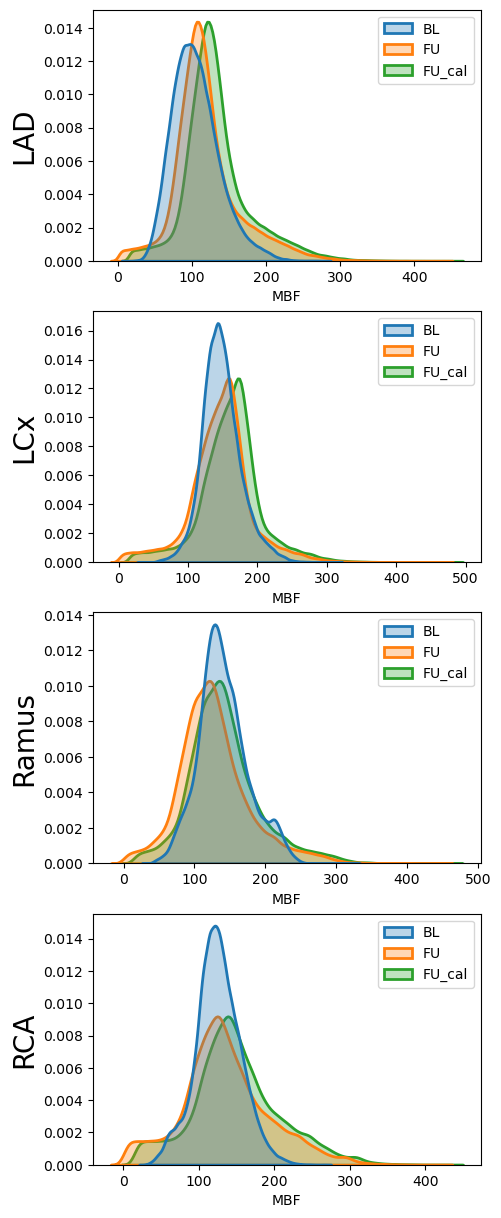

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(5,15))
for i, key in enumerate(MBFData_A.keys()):
    array_B_mapped = ShiftMBF(ref_A, ref_B, MBFData_B[key])
    data = pd.DataFrame({
        "MBF": np.concatenate([MBFData_A[key], MBFData_B[key], array_B_mapped]),
        "Label": ["BL"] * len(MBFData_A[key]) +
                ["FU"] * len(MBFData_B[key]) +
                ["FU_cal"] * len(array_B_mapped)
        })
    
    sns.kdeplot(data = data, x="MBF", hue=data['Label'].tolist(),
                fill=True, common_norm=False, alpha=.3,
                linewidth=2, ax=axes[i], legend=True)
    
    axes[i].set_ylabel(key, fontsize=20)